## Imports

In [2]:
import os
from IPython.core.pylabtools import figsize

os.environ["PROJ_LIB"] = "/home/abernard/miniconda3/envs/geo_clean/share/proj"
os.environ["PROJ_DATA"] = "/home/abernard/miniconda3/envs/geo_clean/share/proj"
os.environ["GDAL_DATA"] = "/home/abernard/miniconda3/envs/geo_clean/share/gdal"

In [3]:
import teledetection # old : import dinamis_sdk
import pystac_client
import pandas as pd
import geopandas as gpd
from matplotlib import pyplot as plt
from path import Path
import pystac_client
import numpy as np
import xarray as xr
xr.set_options(keep_attrs=True)
from path import Path
#import pystac_client
import stackstac
import time
import planetary_computer as pc
#from simplestac.utils import ItemCollection, apply_formula, drop_assets_without_proj


In [4]:
import warnings
from rasterio import logging

In [5]:
from pyproj import CRS

print(CRS.from_epsg(2154))

EPSG:2154


In [6]:
from matplotlib.colors import LogNorm

## Local datas

In [7]:
gdf = gpd.read_file("../data/RNN_limite_poly_l93.shp")

gdf = gdf.set_crs("EPSG:2154")

gdf = gdf.to_crs("EPSG:4326")


gdf2 = gpd.read_file("../data/limite_RI_wgs84.shp")
gdf2 = gdf2.set_crs("EPSG:4326")

/home/abernard/miniconda3/envs/geo_clean/lib/python3.11/site-packages/pyogrio/raw.py:200: RuntimeWarning: organizePolygons() received an unexpected geometry.  Either a polygon with interior rings, or a polygon with less than 4 points, or a non-Polygon geometry.  Return arguments as a collection.
  return ogr_read(
/home/abernard/miniconda3/envs/geo_clean/lib/python3.11/site-packages/pyogrio/raw.py:200: RuntimeWarning: Geometry of polygon of fid 0 cannot be translated to Simple Geometry. All polygons will be contained in a multipolygon.
  return ogr_read(


In [8]:
#virer les warnings de rasterio
warnings.filterwarnings("ignore")
log = logging.getLogger()
log.setLevel(logging.ERROR)

In [9]:
# Load the area of interest
roi_file = "../data/emprise_massane.geojson"
# Lire le fichier GeoJSON
#roi = gpd.read_file(roi_file)
#print(roi.total_bounds)
roi = gdf

## Remote datas

In [10]:
URL = "https://stacapi-cdos.apps.okd.crocc.meso.umontpellier.fr"
api = pystac_client.Client.open(URL)

collections = [(collection.id, collection.title) for collection in api.get_collections()]
pd.set_option('display.max_rows', 150)
pd.DataFrame(collections, columns=['Collection ID', 'Collection Title']).sort_values(by='Collection ID')

,Collection ID,Collection Title
10,FORMSpoT,FORMSpoT
11,FORMSpoT-delta,FORMSpoT-∆
0,becarun,Lidar BECARUN (COPC)
1,cartofeux-lidarhd,Lidar HD point cloud for project CARTO-FEUX
2,cesbio-s2albedo,Albédo de surface Sentinel-2
3,corona-4b,Corona 4B
4,costarica-sentinel-2-l2-spectral-indices,costarica-sentinel-2-l2-spectral-indices
5,costarica-sentinel-2-l3-seasonal-spectral-indices,costarica-sentinel-2-l3-seasonal-spectral-indices
6,costarica-sentinel-2-l3-seasonal-spectral-indi...,costarica-sentinel-2-l3-seasonal-spectral-indi...
7,costarica-sentinel-2-l4-seasonal-diversity-ind...,costarica-sentinel-2-l4-seasonal-diversity-ind...


In [11]:
tile = "MGRS-31TEH"
start_date = "2016-01-01"
end_date = "2026-06-01"
time_range = start_date + "/" + end_date
#time_range = "2024-03-01/2024-03-20"
#cloud_nb = 10
relative_orb = 37
# bbox=[3.00, 42.47, 3.04, 42.5]

# file where the collection will be saved

catalog = pystac_client.Client.open(URL, modifier=teledetection.sign_inplace)
search = catalog.search(
    collections=["sentinel1-rtc"],  ##CDS
    #collections=["sentinel-2-l2a"], ##Planetary
    # bbox=bbox,
    bbox=roi.to_crs(4326).total_bounds,
    datetime=time_range,
    #query={"eo:cloud_cover": {"lt": cloud_nb}},
    #query={"grid:code": {"eq": tile}}
    query={"grid:code": {"eq": tile}, "sat:relative_orbit": {"eq": relative_orb}}
    #query={"s2:mgrs_tile": {"eq": tile},"eo:cloud_cover": {"lt": cloud_nb} },
)
items = search.get_all_items()
print(f"{len(items)} items found")

161 items found


In [12]:
from simplestac.utils import ItemCollection

df = gpd.GeoDataFrame.from_features(items.to_dict(), crs="epsg:4326")

In [13]:
col = ItemCollection(search.item_collection(), clone_items=False).sort_items(by="datetime")
item = col[0]
print(item.assets.keys())

Filled property fields with None when missing in items:
{'updated'}
dict_keys(['MD', 'QL', 'VH', 'VV', 'LIA'])


In [14]:
col.drop_non_raster(inplace=True)
col_non_corrected = col.filter(assets=["VH", "VV", "LIA"]) #CDS_MTD

# incidence angle correction

In [15]:
# correct the incidence angle, and convert to xarray
from simplestac.utils import apply_formula

col_non_corrected.drop_non_raster(inplace=True)

col_non_corrected.apply_items(
    fun=apply_formula, # a function that returns one or more xarray.DataArray
    name="VVnorm1",
    formula="VV*((np.cos(np.deg2rad(45))/np.cos(np.deg2rad(LIA/100)))**1)", #VVnorm
    output_dir="VVnorm1",
    #datetime="2018-01-01/..",
    geometry=roi.geometry,
    inplace=True
)
col_non_corrected.apply_items(
    fun=apply_formula, # a function that returns one or more xarray.DataArray
    name="VHnorm1",
    formula="VH*((np.cos(np.deg2rad(45))/np.cos(np.deg2rad(LIA/100)))**1)", #VHnorm
    output_dir="VHnorm1",
    #datetime="2018-01-01/..",
    geometry=roi.geometry,
    inplace=True
)

100%|██████████| 161/161 [00:00<00:00, 266.70it/s]


In [16]:
xar_nc = col_non_corrected.to_xarray(geometry=roi.geometry, epsg=4326)
# #xar = col.to_xarray(geometry= geometrie)
xar_nc.drop_duplicates('time')

<xarray.DataArray 'stackstac-a8788f9c25c2a580ebef8954276633cd' (time: 161,
                                                                band: 5,
                                                                y: 354, x: 335)> Size: 764MB
dask.array<getitem, shape=(161, 5, 354, 335), dtype=float64, chunksize=(1, 1, 354, 335), chunktype=numpy.ndarray>
Coordinates: (12/39)
  * time                                   (time) datetime64[ns] 1kB 2022-01-...
    id                                     (time) <U31 20kB 'S1A_20220111T055...
    s1:total_slices                        (time) <U2 1kB '27' '27' ... '36'
    sat:absolute_orbit                     (time) int64 1kB 41409 41584 ... 7558
    updated                                (time) object 1kB None None ... None
    s1:product_identifier                  (time) <U72 46kB 'S1A_IW_GRDH_1SDV...
    ...                                     ...
    sar:pixel_spacing_range                float64 8B 10.0
    grid:code                              <U10 40B 'MGRS-31TEH'
    proj:code                              <U10 40B 'EPSG:32631'
    proj:epsg                              int64 8B 32631
    epsg                                   int64 8B 4326
    spatial_ref                            int64 8B 0
Attributes:
    spec:           RasterSpec(epsg=4326, bounds=(np.float64(2.99970159970225...
    resolution_xy:  (np.float64(0.00012170162283764441), np.float64(9.0045532...

## compute metrics

In [17]:
# compute RVI

vvn1 = xar_nc.sel(band="VVnorm1")
vhn1 = xar_nc.sel(band="VHnorm1")

rvi1 = (4 * vhn1) / (vvn1 + vhn1)

# on force la structure band
rvi1 = rvi1.expand_dims("band")
rvi1 = rvi1.assign_coords(band=["RVI1"])

In [18]:
# vv/vh
vvn_nc = xar_nc.sel(band="VVnorm1")
vhn_nc = xar_nc.sel(band="VHnorm1")

vvvh1 = vvn_nc / vhn_nc

# on force la structure band
vvvh1 = vvvh1.expand_dims("band")
vvvh1 = vvvh1.assign_coords(band=["vvvh1"])

In [19]:
xar_corrected = xr.concat(
    [xar_nc, rvi1, vvvh1],
    dim="band"
)

In [20]:
# passer en db
xar_corrected_db = 10 * np.log10(xar_corrected)

In [21]:
print(xar_corrected_db.band.values)

['VH' 'VV' 'LIA' 'VVnorm1' 'VHnorm1' 'RVI1' 'vvvh1']


## phenology

In [22]:
# Découpage sur la RI
xar_clipped = xar_corrected_db.rio.clip(
    gdf2.geometry,
    gdf2.crs,
    drop=True
)

In [23]:
xar_clipped

<xarray.DataArray 'stackstac-a8788f9c25c2a580ebef8954276633cd' (time: 161,
                                                                band: 7, y: 62,
                                                                x: 39)> Size: 22MB
dask.array<getitem, shape=(161, 7, 62, 39), dtype=float64, chunksize=(1, 1, 62, 39), chunktype=numpy.ndarray>
Coordinates: (12/39)
  * time                                   (time) datetime64[ns] 1kB 2022-01-...
    id                                     (time) <U31 20kB 'S1A_20220111T055...
    s1:total_slices                        (time) <U2 1kB '27' '27' ... '36'
    sat:absolute_orbit                     (time) int64 1kB 41409 41584 ... 7558
    updated                                (time) object 1kB None None ... None
    s1:product_identifier                  (time) <U72 46kB 'S1A_IW_GRDH_1SDV...
    ...                                     ...
    sar:pixel_spacing_range                float64 8B 10.0
    grid:code                              <U10 40B 'MGRS-31TEH'
    proj:code                              <U10 40B 'EPSG:32631'
    proj:epsg                              int64 8B 32631
    epsg                                   int64 8B 4326
    spatial_ref                            int64 8B 0
Attributes:
    spec:           RasterSpec(epsg=4326, bounds=(np.float64(2.99970159970225...
    resolution_xy:  (np.float64(0.00012170162283764441), np.float64(9.0045532...

In [24]:
# metadata for the df subsets

meta = pd.DataFrame({
    "time": xar_clipped.time.values,
    "orbit_state": xar_clipped["sat:orbit_state"].values,
    "platform": xar_clipped["platform"].values,
    "relative_orbit": xar_clipped["sat:relative_orbit"].values,
    "absolute_orbit": xar_clipped["sat:absolute_orbit"].values,
})

In [25]:
xar_clipped = xar_clipped.chunk({
    "time": -1,
    "band": -1
})

In [26]:
xar_clipped_ld = (
    xar_clipped
    .load()          # charge une fois
    .reset_coords(drop=True)
)

In [27]:
df = (
    xar_clipped_ld
    .median(("x", "y"))
    .to_dataframe("value")
    .reset_index()
)

df = df.pivot(
    index="time",
    columns="band",
    values="value"
).reset_index()

In [28]:
df = df.merge(meta, on="time")

In [29]:
print(df)

                          time        LIA      RVI1         VH    VHnorm1  \
0   2022-01-11 05:52:58.431000  37.904611 -0.510549 -16.670071 -14.969470   
1   2022-01-23 05:52:57.768000  37.904611 -0.766878 -17.730352 -15.959669   
2   2022-02-04 05:52:57.143000  37.904611 -0.547922 -16.973681 -15.161914   
3   2022-02-16 05:52:57.087000  37.904611 -0.654103 -17.278442 -15.383095   
4   2022-02-28 05:52:56.997000  37.904611 -1.022723 -17.790466 -15.901108   
..                         ...        ...       ...        ...        ...   
156 2026-04-14 05:51:58.062791  37.904611 -0.575221 -18.264279 -16.477790   
157 2026-04-20 05:52:50.356179  37.903907 -1.406668 -19.157191 -17.407417   
158 2026-04-26 05:51:58.689443  37.904963 -1.394154 -18.886825 -17.147482   
159 2026-05-02 05:52:49.990556  37.903555 -1.361805 -19.026055 -17.281580   
160 2026-05-08 05:51:59.459304  37.905315 -1.367711 -18.696457 -17.012119   

            VV    VVnorm1     vvvh1 orbit_state     platform  relative_orbi

## plots

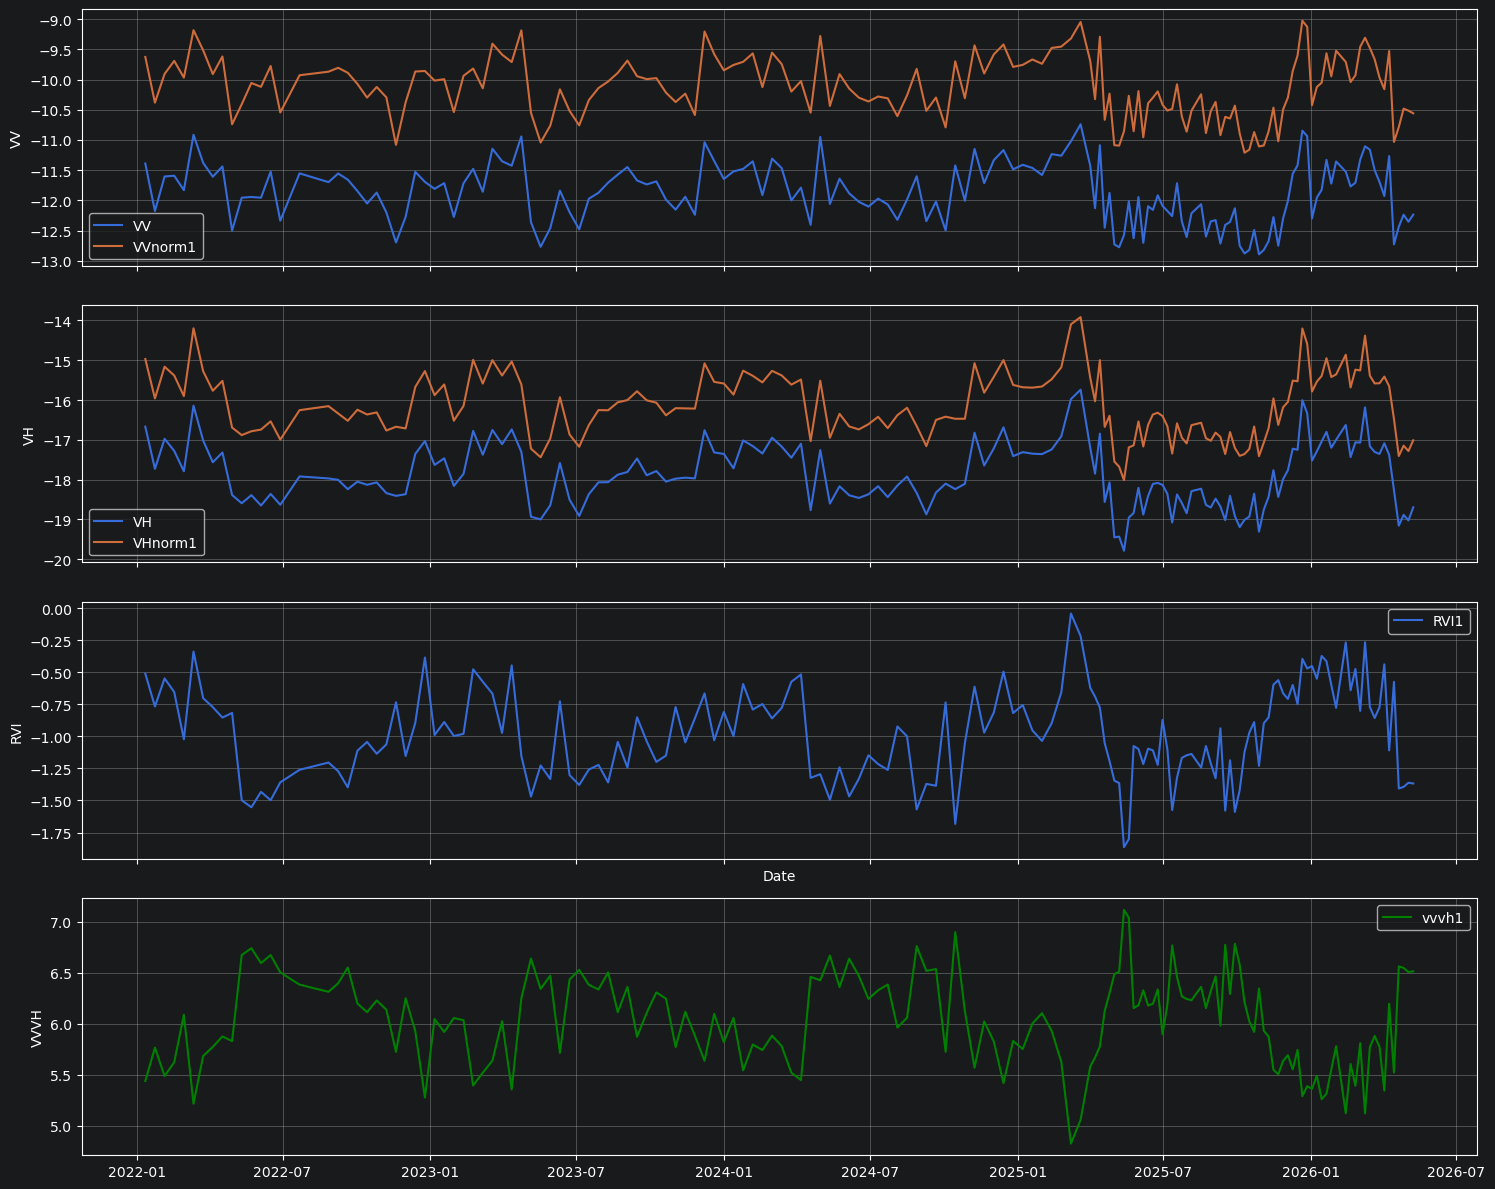

In [30]:
fig, axes = plt.subplots(
    4, 1,
    figsize=(15, 12),
    sharex=True
)

# -------- VV --------
vv_cols = ["VV", "VVnorm1"]

for c in vv_cols:
    axes[0].plot(df["time"], df[c], label=c)

axes[0].set_ylabel("VV")
axes[0].legend()
axes[0].grid(True)

# -------- VH --------
vh_cols = ["VH", "VHnorm1"]

for c in vh_cols:
    axes[1].plot(df["time"], df[c], label=c)

axes[1].set_ylabel("VH")
axes[1].legend()
axes[1].grid(True)

# -------- RVI --------
rvi_cols = ["RVI1"]

for c in rvi_cols:
    axes[2].plot(df["time"], df[c], label=c)

axes[2].set_ylabel("RVI")
axes[2].set_xlabel("Date")
axes[2].legend()
axes[2].grid(True)

# -------- VVVH --------
vvvh1_cols = ["vvvh1"]

for c in vvvh1_cols:
    axes[3].plot(df["time"], df[c], label=c, color = "green")

axes[3].set_ylabel("VVVH")
axes[3].legend()
axes[3].grid(True)

plt.tight_layout()
plt.show()

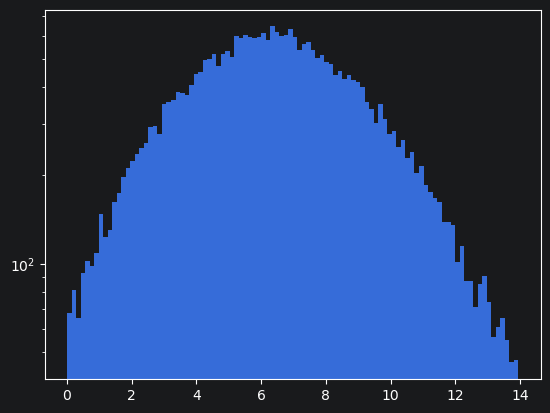

In [31]:
img = xar_corrected_db.sel(
    band="vvvh1",
    time="2025-07-06"
).isel(time=0).values

# Retirer les NaN
vals = img[np.isfinite(img)]

# Garder les 98 % centraux
q2, q98 = np.percentile(vals, [2, 98])

plt.hist(vals[(vals >= q2) & (vals <= q98)], bins=100)
plt.yscale("log")
plt.show()

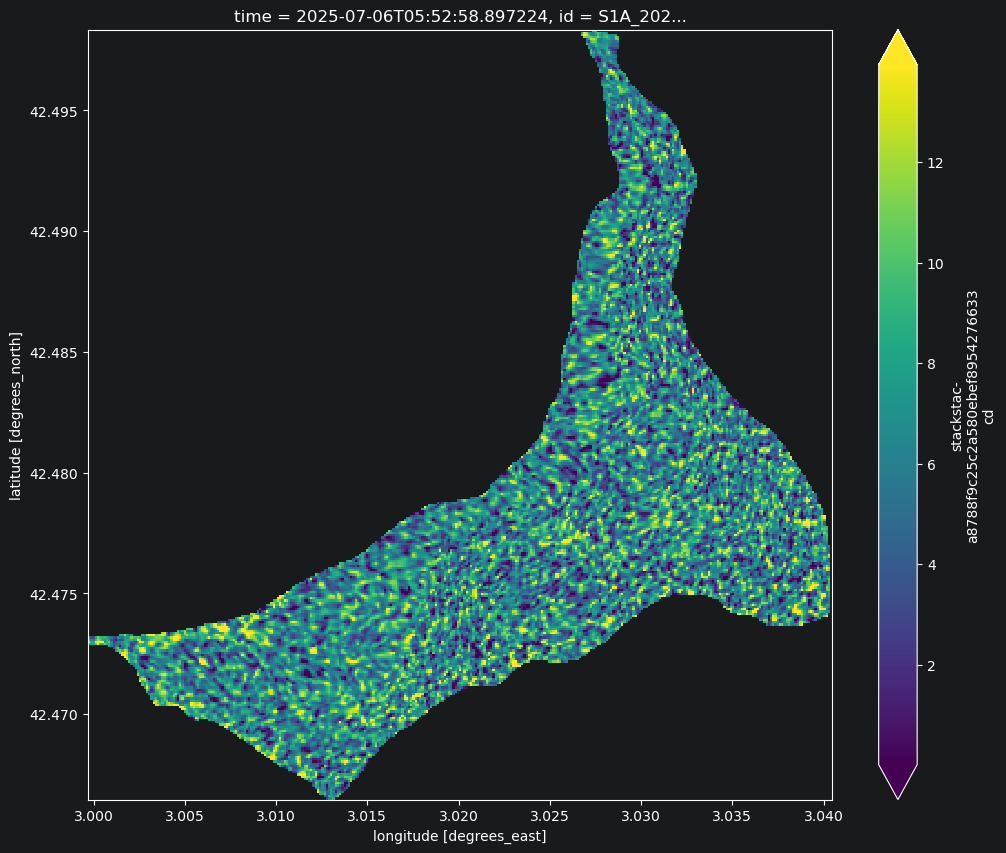

In [32]:
print(xar_corrected_db.sel(
    band="vvvh1",
    time="2025-07-06"
).isel(time=0).plot(figsize=(12,10), robust = True))

## lets try to make mean images at a given temporal res

In [41]:
vvvh_2m = (
    xar_corrected_db
    .sel(band="vvvh1")
    .resample(time="2M")
    .median()
)

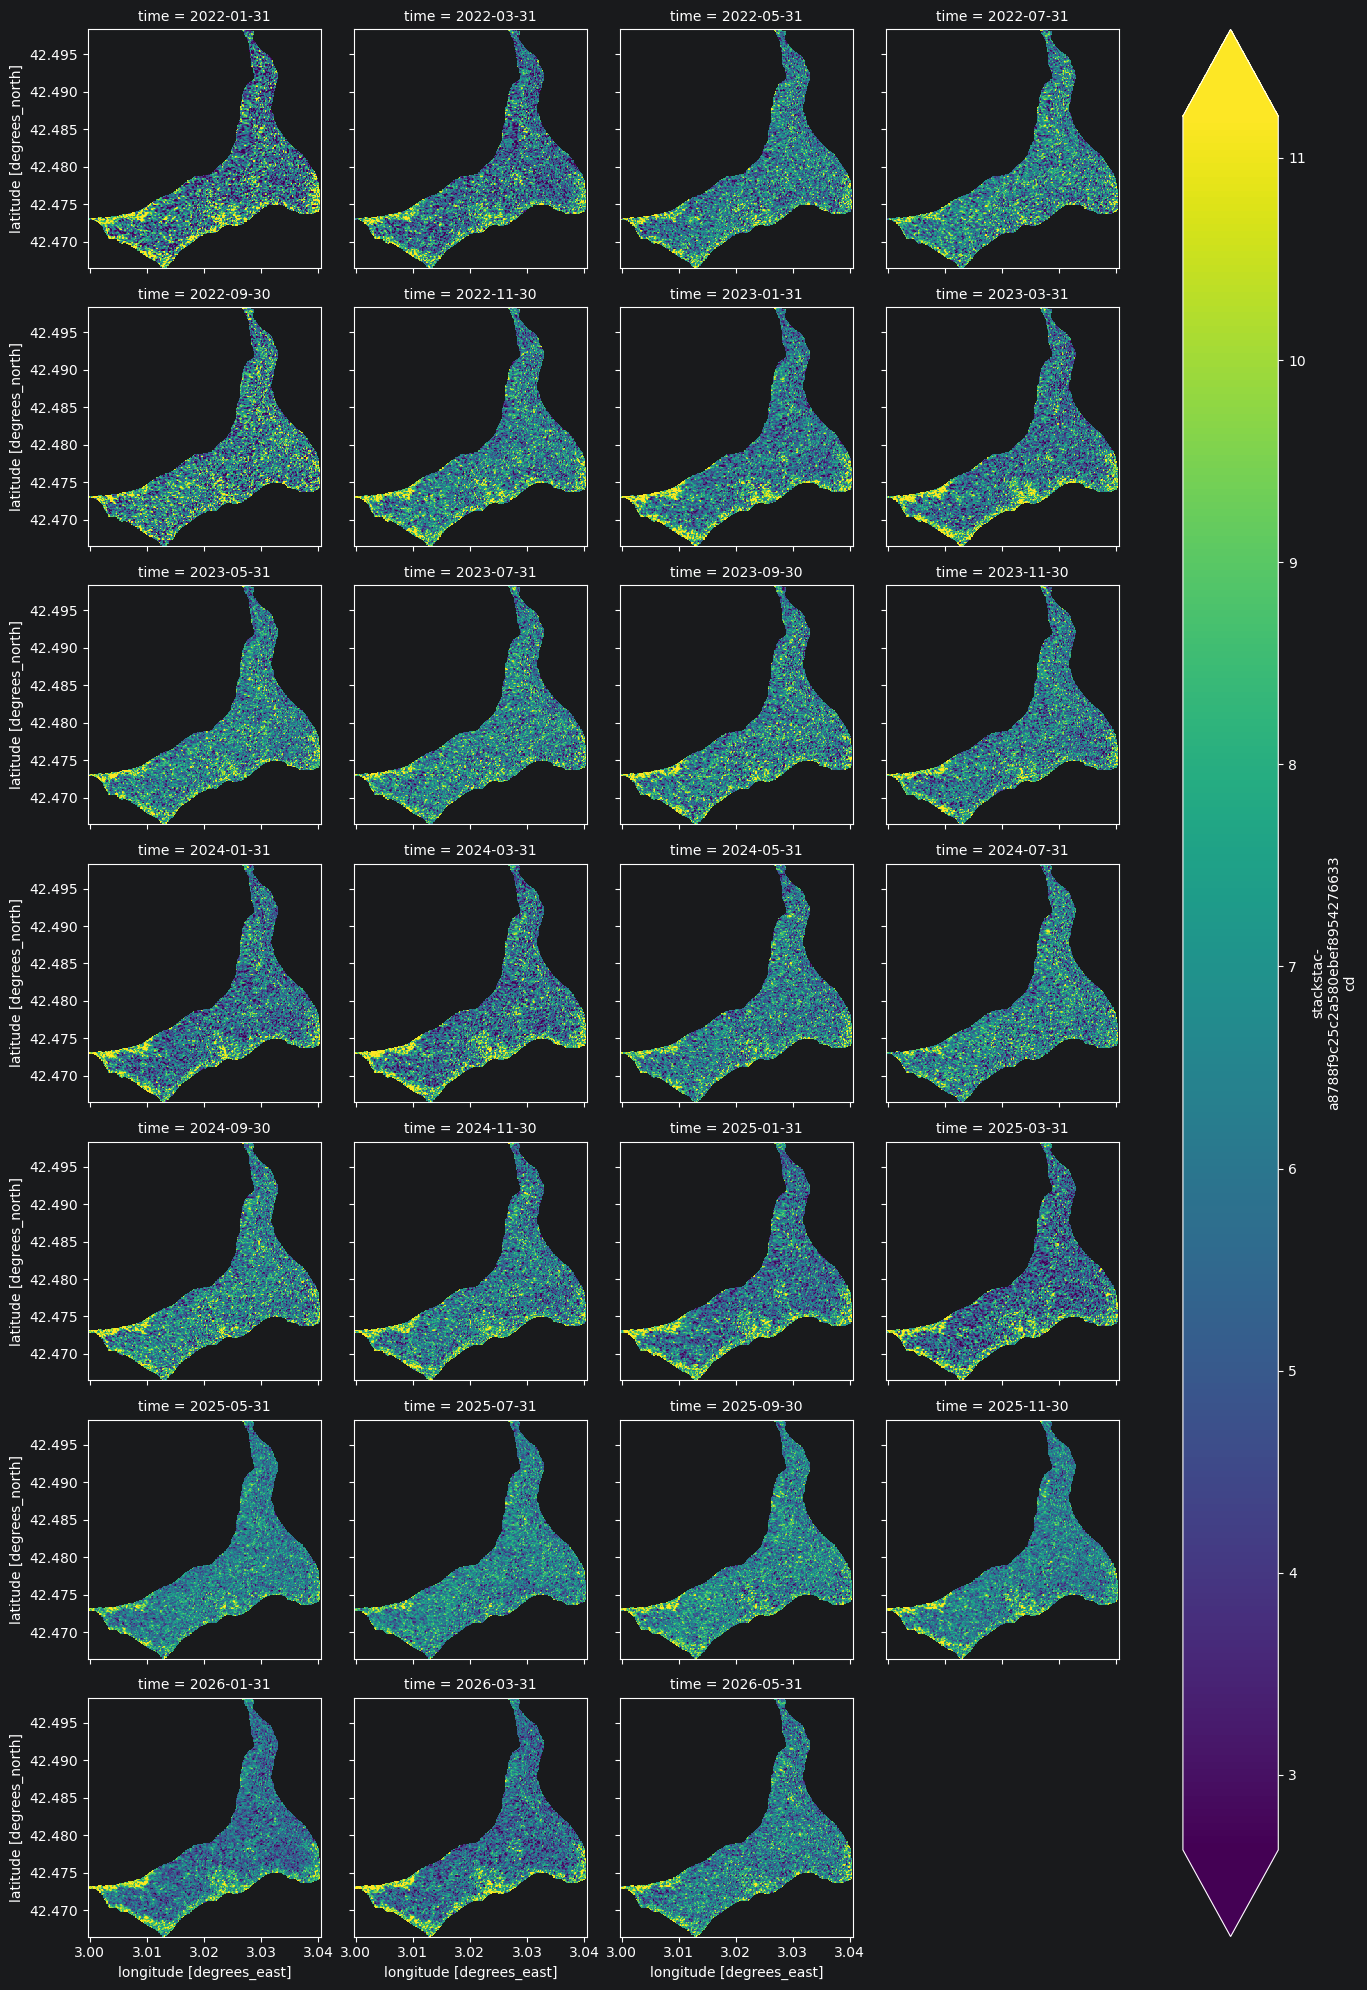

In [42]:
vvvh_2m.plot(
    col="time",
    col_wrap=4,
    figsize=(14, 20),
    robust=True,
    cmap="viridis"
)

In [43]:
vvvh_1y = (
    xar_corrected_db
    .sel(band="vvvh1")
    .resample(time="1Y")
    .median()
)

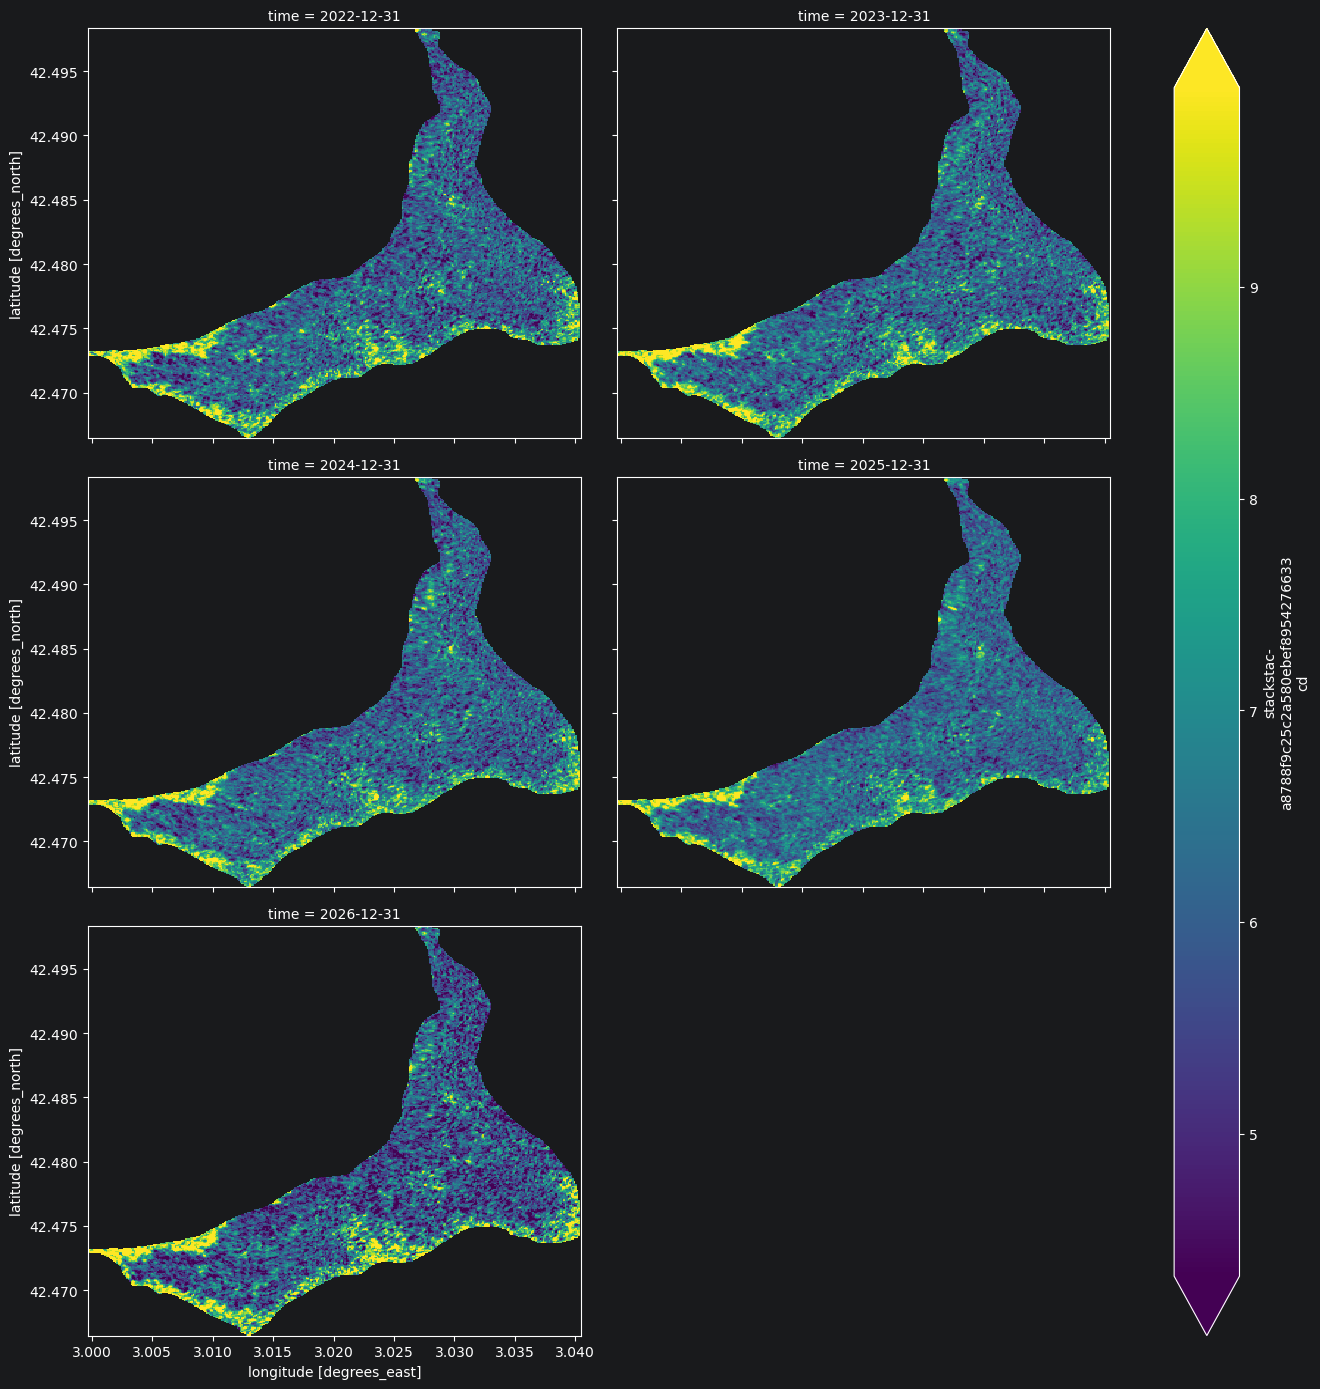

In [51]:
vvvh_1y.plot(
    col="time",
    col_wrap=2,
    figsize=(14, 14),
    robust=True,
    cmap="viridis"
)